In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

In [3]:
X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],
    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],
    [20, 20]
])

print(X)

[[ 1  2]
 [ 1  3]
 [ 2  2]
 [ 2  3]
 [ 8  8]
 [ 9  8]
 [ 8  9]
 [ 9  9]
 [20 20]]


In [4]:
dbscan = DBSCAN(eps=1.5, min_samples=2)

labels = dbscan.fit_predict(X)

print("Cluster Labels:")
print(labels)

Cluster Labels:
[ 0  0  0  0  1  1  1  1 -1]


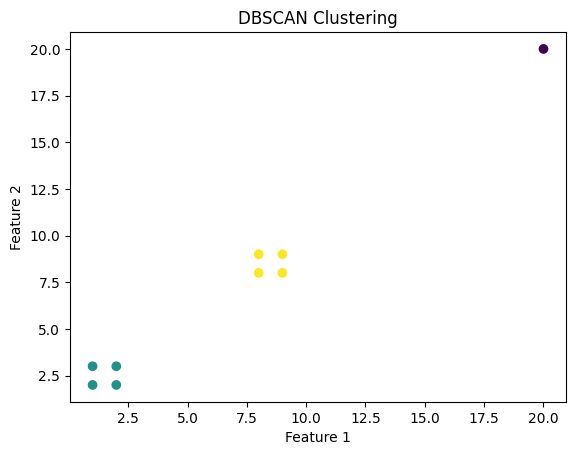

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=labels)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.show()

In [6]:
core_points = dbscan.core_sample_indices_

print("Core Point Indices:")
print(core_points)

print("\nCore Points:")
print(X[core_points])

noise_points = X[labels == -1]

print("\nNoise Points:")
print(noise_points)

Core Point Indices:
[0 1 2 3 4 5 6 7]

Core Points:
[[1 2]
 [1 3]
 [2 2]
 [2 3]
 [8 8]
 [9 8]
 [8 9]
 [9 9]]

Noise Points:
[[20 20]]


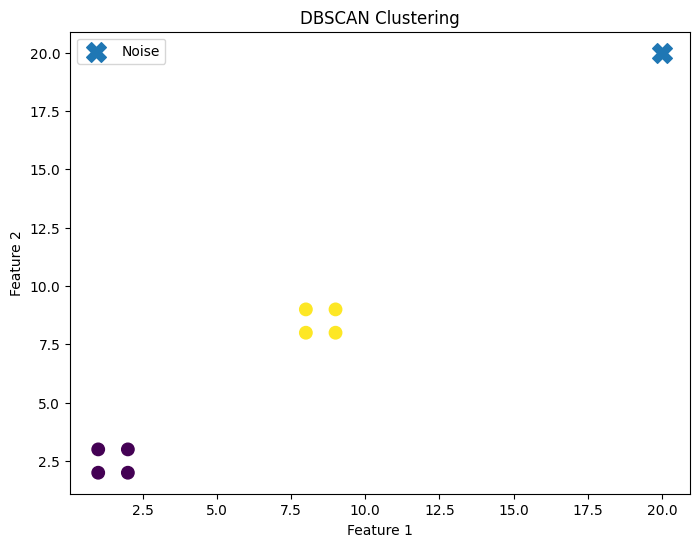

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[labels != -1, 0],
    X[labels != -1, 1],
    c=labels[labels != -1],
    s=80
)

plt.scatter(
    X[labels == -1, 0],
    X[labels == -1, 1],
    marker='X',
    s=200,
    label='Noise'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

In [8]:
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", list(labels).count(-1))
print("Cluster Labels:", labels)

Number of clusters: 2
Number of noise points: 1
Cluster Labels: [ 0  0  0  0  1  1  1  1 -1]


In [9]:
import pandas as pd

result = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])

result["Cluster"] = labels

result["Type"] = "Border"

result.loc[dbscan.core_sample_indices_, "Type"] = "Core"
result.loc[labels == -1, "Type"] = "Noise"

print(result)

   Feature 1  Feature 2  Cluster   Type
0          1          2        0   Core
1          1          3        0   Core
2          2          2        0   Core
3          2          3        0   Core
4          8          8        1   Core
5          9          8        1   Core
6          8          9        1   Core
7          9          9        1   Core
8         20         20       -1  Noise


In [10]:
X2 = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],
    [3.2, 2.5],   # possible border point
    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],
    [20, 20]      # noise
])

print(X2)

[[ 1.   2. ]
 [ 1.   3. ]
 [ 2.   2. ]
 [ 2.   3. ]
 [ 3.2  2.5]
 [ 8.   8. ]
 [ 9.   8. ]
 [ 8.   9. ]
 [ 9.   9. ]
 [20.  20. ]]


In [12]:
dbscan2 = DBSCAN(eps=1.5, min_samples=4)

labels2 = dbscan2.fit_predict(X2)

print("Cluster Labels:")
print(labels2)

Cluster Labels:
[ 0  0  0  0  0  1  1  1  1 -1]


In [13]:
core_indices = dbscan2.core_sample_indices_

result2 = pd.DataFrame(
    X2,
    columns=["Feature 1", "Feature 2"]
)

result2["Cluster"] = labels2
result2["Type"] = "Border"

result2.loc[core_indices, "Type"] = "Core"
result2.loc[labels2 == -1, "Type"] = "Noise"

print(result2)

   Feature 1  Feature 2  Cluster    Type
0        1.0        2.0        0    Core
1        1.0        3.0        0    Core
2        2.0        2.0        0    Core
3        2.0        3.0        0    Core
4        3.2        2.5        0  Border
5        8.0        8.0        1    Core
6        9.0        8.0        1    Core
7        8.0        9.0        1    Core
8        9.0        9.0        1    Core
9       20.0       20.0       -1   Noise


In [14]:
X2 = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],
    [3, 2],       # border candidate
    [8, 8],
    [9, 8],
    [8, 9],
    [9, 9],
    [20, 20]      # noise
])

print(X2)

[[ 1  2]
 [ 1  3]
 [ 2  2]
 [ 2  3]
 [ 3  2]
 [ 8  8]
 [ 9  8]
 [ 8  9]
 [ 9  9]
 [20 20]]


In [15]:
dbscan2 = DBSCAN(eps=1.5, min_samples=4)

labels2 = dbscan2.fit_predict(X2)

print("Cluster Labels:")
print(labels2)

Cluster Labels:
[ 0  0  0  0  0  1  1  1  1 -1]


In [16]:
core_indices = dbscan2.core_sample_indices_

result2 = pd.DataFrame(
    X2,
    columns=["Feature 1", "Feature 2"]
)

result2["Cluster"] = labels2
result2["Type"] = "Border"

result2.loc[core_indices, "Type"] = "Core"
result2.loc[labels2 == -1, "Type"] = "Noise"

print(result2)

   Feature 1  Feature 2  Cluster    Type
0          1          2        0    Core
1          1          3        0    Core
2          2          2        0    Core
3          2          3        0    Core
4          3          2        0  Border
5          8          8        1    Core
6          9          8        1    Core
7          8          9        1    Core
8          9          9        1    Core
9         20         20       -1   Noise


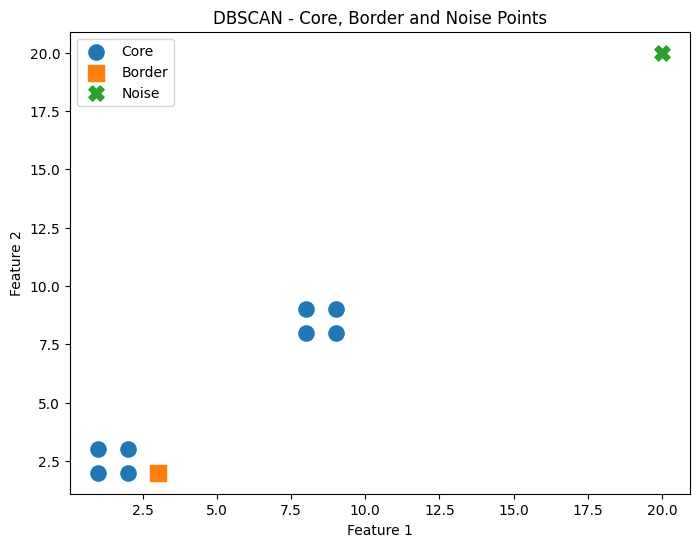

In [17]:
plt.figure(figsize=(8, 6))

for point_type, marker in [
    ("Core", "o"),
    ("Border", "s"),
    ("Noise", "X")
]:
    points = X2[result2["Type"].values == point_type]

    if len(points) > 0:
        plt.scatter(
            points[:, 0],
            points[:, 1],
            marker=marker,
            s=120,
            label=point_type
        )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN - Core, Border and Noise Points")
plt.legend()
plt.show()

K-Means vs DBSCAN

| Feature | K-Means | DBSCAN |
|---|---|---|
| Type | Centroid-based clustering | Density-based clustering |
| Learning | Unsupervised | Unsupervised |
| Number of clusters | Must specify K | Not required |
| Main parameters | n_clusters | eps, min_samples |
| Main idea | Assign points to nearest centroid | Group points in dense regions |
| Center | Uses centroids | Does not use centroids |
| Cluster shape | Works well with compact/spherical clusters | Can find irregular/non-convex clusters |
| Outliers | Sensitive to outliers | Can identify noise/outliers |
| Noise detection | No | Yes |
| Noise label | Not applicable | -1 in scikit-learn |
| Distance/Density | Distance from centroid | Density of neighboring points |
| Core/Border points | No | Yes |
| Elbow method | Can be used | Not used for choosing K |
| Silhouette score | Can be used | Can also be used when valid clusters exist |